<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week8/Semana8_Actv_8_Freddy_Forero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Universidad de Cundinamarca  
## Deep Learning  
## CNN + Transfer Learning — Clasificación de imágenes  
## Freddy Alexander Forero Rojas


### Configuración del Entorno

In [1]:
# ── Verificar GPU en Colab
import subprocess, sys

try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                             '--format=csv,noheader'], capture_output=True, text=True)
    if result.returncode == 0:
        print(f" GPU disponible: {result.stdout.strip()}")
    else:
        print(" GPU no detectada — se usará CPU (más lento)")
        print("   En Colab: Entorno de ejecución → Cambiar tipo de entorno → GPU")
except FileNotFoundError:
    print("nvidia-smi no encontrado — posiblemente CPU")

# ── Imports principales
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Semilla global
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"\n{'='*50}")
print(f"  TensorFlow : {tf.__version__}")
print(f"  Keras      : {keras.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Dispositivos: {[d.name for d in tf.config.list_physical_devices()]}")
print(f"{'='*50}")

nvidia-smi no encontrado — posiblemente CPU

  TensorFlow : 2.19.0
  Keras      : 3.13.2
  NumPy      : 2.0.2
  Dispositivos: ['/physical_device:CPU:0']


## Pipeline de Datos — Carga, Preprocesamiento y Partición

In [2]:
# ── 1.1 Cargar CIFAR-10
print("Cargando CIFAR-10...")
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

CLASES = ['Avión','Auto','Pájaro','Gato','Ciervo',
          'Perro','Rana','Caballo','Barco','Camión']
N_CLASES = len(CLASES)

print(f"\nDataset completo:")
print(f"  X_train_full : {X_train_full.shape}  dtype={X_train_full.dtype}")
print(f"  X_test       : {X_test.shape}")
print(f"  Clases       : {CLASES}")

# ── 1.2 Subconjunto para entrenamiento rápido (ajustable)
N_TRAIN = 10000  # Aumentar si hay GPU disponible
N_TEST  =  2000

idx_train = np.random.choice(len(X_train_full), N_TRAIN, replace=False)
idx_test  = np.random.choice(len(X_test),       N_TEST,  replace=False)

X_tr_raw = X_train_full[idx_train]
y_tr_raw = y_train_full[idx_train].flatten()
X_te_raw = X_test[idx_test]
y_te_raw = y_test[idx_test].flatten()

# ── 1.3 Normalización
X_tr_norm = X_tr_raw.astype('float32') / 255.0
X_te_norm = X_te_raw.astype('float32') / 255.0

# ── 1.4 Partición train/validación (80/20)
split = int(0.8 * N_TRAIN)
X_train, X_val = X_tr_norm[:split], X_tr_norm[split:]
y_train, y_val = y_tr_raw[:split],  y_tr_raw[split:]
X_test_final,  y_test_final = X_te_norm, y_te_raw

print(f"\nPartición final:")
print(f"  Entrenamiento : {X_train.shape}")
print(f"  Validación    : {X_val.shape}")
print(f"  Prueba        : {X_test_final.shape}")
print(f"  Rango valores : [{X_train.min():.3f}, {X_train.max():.3f}]")

Cargando CIFAR-10...

Dataset completo:
  X_train_full : (50000, 32, 32, 3)  dtype=uint8
  X_test       : (10000, 32, 32, 3)
  Clases       : ['Avión', 'Auto', 'Pájaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

Partición final:
  Entrenamiento : (8000, 32, 32, 3)
  Validación    : (2000, 32, 32, 3)
  Prueba        : (2000, 32, 32, 3)
  Rango valores : [0.000, 1.000]


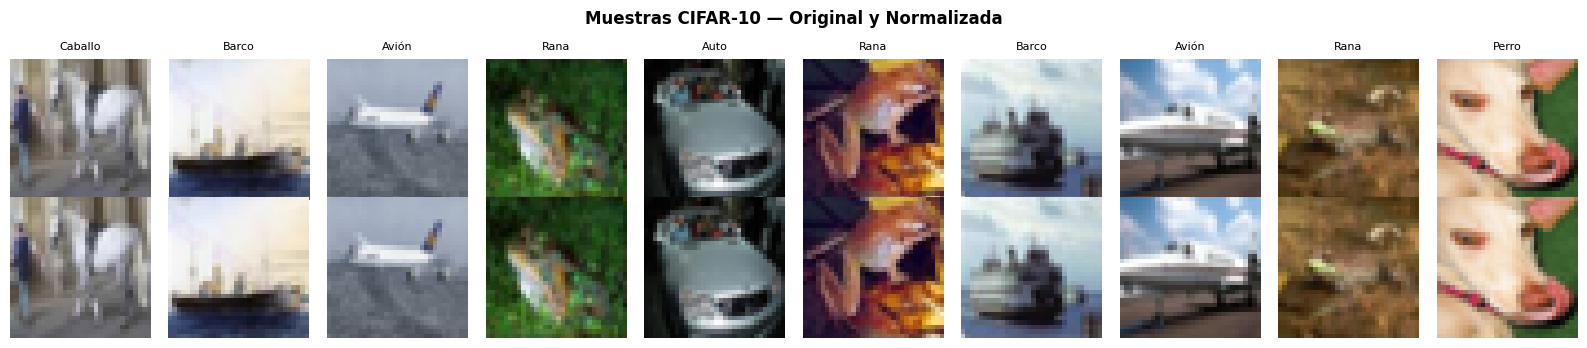

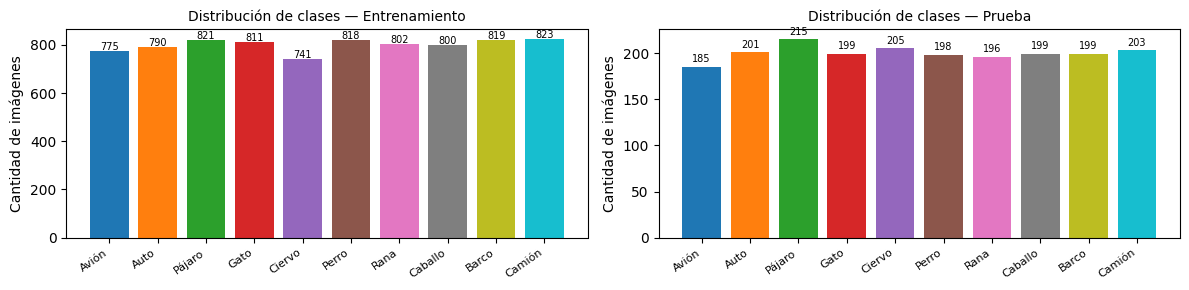

✅ Pipeline de datos completo


In [3]:
# ── 1.5 Visualizar muestras del dataset
fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
fig.suptitle('Muestras CIFAR-10 — Original y Normalizada', fontsize=12, fontweight='bold')

for i in range(10):
    # Fila 1: imágenes originales
    axes[0, i].imshow(X_tr_raw[i])
    axes[0, i].set_title(CLASES[y_tr_raw[i]], fontsize=8)
    axes[0, i].axis('off')
    # Fila 2: normalizadas
    axes[1, i].imshow(X_train[i])
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original\n(0-255)', fontsize=8, rotation=90)
axes[1, 0].set_ylabel('Normaliz.\n(0-1)', fontsize=8, rotation=90)
plt.tight_layout()
plt.savefig('figures/01_muestras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, (y, titulo) in zip(axes, [(y_train,'Entrenamiento'),(y_test_final,'Prueba')]):
    conteo = [np.sum(y==i) for i in range(N_CLASES)]
    bars = ax.bar(CLASES, conteo, color=plt.cm.tab10(np.arange(N_CLASES)/N_CLASES))
    ax.set_title(f'Distribución de clases — {titulo}', fontsize=10)
    ax.set_xticklabels(CLASES, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Cantidad de imágenes')
    for bar, v in zip(bars, conteo):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(v), ha='center', fontsize=7)
plt.tight_layout()
plt.savefig('figures/02_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pipeline de datos completo")

## Modelo A — CNN Base (entrenada desde cero)


In [4]:
def construir_cnn_base(input_shape=(32, 32, 3), n_clases=10):
    """CNN propia entrenada desde cero."""
    model = models.Sequential(name='CNN_Base')

    # ── Bloque 1: extracción de características de bajo nivel
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Bloque 2: características de nivel medio
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Bloque 3: características de alto nivel
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Clasificador
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(n_clases, activation='softmax'))

    return model


cnn_base = construir_cnn_base()
cnn_base.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_base.summary()

total_params = cnn_base.count_params()
print(f"\n{'='*50}")
print(f"  Parámetros totales: {total_params:,}")
print(f"  Parámetros (~MB) : {total_params*4/1e6:.2f} MB")
print(f"{'='*50}")

Model: "CNN_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)


  Parámetros totales: 668,842
  Parámetros (~MB) : 2.68 MB


In [6]:
# ── Data Augmentation para CNN base
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

# Callbacks
cb_cnn = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1)
]

print("Iniciando entrenamiento CNN Base...")
print(f"  Épocas máx : 40 (con EarlyStopping)")
print(f"  Batch size : 64")
print(f"  Datos      : {X_train.shape[0]} train / {X_val.shape[0]} val")
print("-" * 50)

t0 = time.time()
hist_cnn = cnn_base.fit(
    datagen.flow(X_train, y_train, batch_size=64, seed=SEED),
    steps_per_epoch=len(X_train) // 64,
    epochs=2,
    validation_data=(X_val, y_val),
    callbacks=cb_cnn,
    verbose=1
)
t_cnn = time.time() - t0

# Evaluación
loss_cnn, acc_cnn = cnn_base.evaluate(X_test_final, y_test_final, verbose=0)
print(f"\n{'='*50}")
print(f"  CNN BASE — RESULTADOS FINALES")
print(f"  Tiempo entrenamiento : {t_cnn/60:.1f} min")
print(f"  Épocas ejecutadas    : {len(hist_cnn.history['loss'])}")
print(f"  Test Loss            : {loss_cnn:.4f}")
print(f"  Test Accuracy        : {acc_cnn*100:.2f}%")
print(f"{'='*50}")

Iniciando entrenamiento CNN Base...
  Épocas máx : 40 (con EarlyStopping)
  Batch size : 64
  Datos      : 8000 train / 2000 val
--------------------------------------------------
Epoch 1/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 535ms/step - accuracy: 0.4059 - loss: 1.7267 - val_accuracy: 0.1395 - val_loss: 3.0860 - learning_rate: 0.0010
Epoch 2/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 493ms/step - accuracy: 0.4387 - loss: 1.5862 - val_accuracy: 0.3265 - val_loss: 1.8165 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.

  CNN BASE — RESULTADOS FINALES
  Tiempo entrenamiento : 2.2 min
  Épocas ejecutadas    : 2
  Test Loss            : 1.8461
  Test Accuracy        : 33.70%


## Modelo B — Transfer Learning con MobileNetV2


In [7]:
# ── Redimensionar imágenes para MobileNetV2 (96×96)
IMG_SIZE_TL = 96  # MobileNetV2 mínimo: 96×96

def redimensionar(X, size=IMG_SIZE_TL):
    return tf.image.resize(X, (size, size)).numpy()

print(f"Redimensionando imágenes 32×32 → {IMG_SIZE_TL}×{IMG_SIZE_TL}...")
X_train_tl = redimensionar(X_train)
X_val_tl   = redimensionar(X_val)
X_test_tl  = redimensionar(X_test_final)
print(f"Forma final: {X_train_tl.shape}")

# ── Construir modelo con Transfer Learning
def construir_transfer_learning(img_size=IMG_SIZE_TL, n_clases=10):
    # Base preentrenada — pesos ImageNet, sin la capa de clasificación
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # Fase 1: congelar todo

    # Cabezal de clasificación personalizado
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_clases, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_TL')
    return model, base


tl_model, base_model = construir_transfer_learning()
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen compacto
params_total = tl_model.count_params()
params_train = sum([tf.size(v).numpy() for v in tl_model.trainable_variables])
print(f"\nMobileNetV2 — Parámetros:")
print(f"  Totales     : {params_total:,}")
print(f"  Entrenables : {params_train:,}  ({params_train/params_total*100:.1f}%)")
print(f"  Congelados  : {params_total-params_train:,}  ({(params_total-params_train)/params_total*100:.1f}%)")

Redimensionando imágenes 32×32 → 96×96...
Forma final: (8000, 96, 96, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MobileNetV2 — Parámetros:
  Totales     : 2,423,242
  Entrenables : 165,258  (6.8%)
  Congelados  : 2,257,984  (93.2%)


In [9]:
# ── FASE 1: Feature Extraction (base congelada)
print("FASE 1 — Feature Extraction (capas base congeladas)")
print("-" * 55)

cb_tl_f1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=6,
                            restore_best_weights=True, verbose=1)
]

t1 = time.time()
hist_tl_f1 = tl_model.fit(
    X_train_tl, y_train,
    batch_size=64, epochs=2,
    validation_data=(X_val_tl, y_val),
    callbacks=cb_tl_f1,
    verbose=1
)
t1_dur = time.time() - t1

loss_f1, acc_f1 = tl_model.evaluate(X_test_tl, y_test_final, verbose=0)
print(f"\nFase 1 — Test Accuracy: {acc_f1*100:.2f}% | Loss: {loss_f1:.4f}")
print(f"Tiempo Fase 1: {t1_dur/60:.1f} min")

FASE 1 — Feature Extraction (capas base congeladas)
-------------------------------------------------------
Epoch 1/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 570ms/step - accuracy: 0.6568 - loss: 0.9901 - val_accuracy: 0.7195 - val_loss: 0.7982
Epoch 2/2
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 527ms/step - accuracy: 0.7452 - loss: 0.7441 - val_accuracy: 0.7450 - val_loss: 0.7352
Restoring model weights from the end of the best epoch: 2.

Fase 1 — Test Accuracy: 75.75% | Loss: 0.7265
Tiempo Fase 1: 2.4 min


In [11]:
# ── FASE 2: Fine-tuning (descongelar últimas capas)
print("FASE 2 — Fine-tuning (últimas 30 capas descongeladas)")
print("-" * 55)

base_model.trainable = True
# Congelar todas las capas excepto las últimas 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# LR muy bajo para no destruir pesos preentrenados
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

params_train_f2 = sum([tf.size(v).numpy() for v in tl_model.trainable_variables])
print(f"Parámetros entrenables en Fase 2: {params_train_f2:,}")

cb_tl_f2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1)
]

t2 = time.time()
hist_tl_f2 = tl_model.fit(
    X_train_tl, y_train,
    batch_size=32, epochs=2,
    validation_data=(X_val_tl, y_val),
    callbacks=cb_tl_f2,
    verbose=1
)
t2_dur = time.time() - t2

loss_tl, acc_tl = tl_model.evaluate(X_test_tl, y_test_final, verbose=0)
t_tl = t1_dur + t2_dur

print(f"\n{'='*50}")
print(f"  TRANSFER LEARNING — RESULTADOS FINALES")
print(f"  Tiempo total (F1+F2) : {t_tl/60:.1f} min")
print(f"  Test Loss            : {loss_tl:.4f}")
print(f"  Test Accuracy        : {acc_tl*100:.2f}%")
print(f"{'='*50}")

FASE 2 — Fine-tuning (últimas 30 capas descongeladas)
-------------------------------------------------------
Parámetros entrenables en Fase 2: 1,691,658
Epoch 1/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 397ms/step - accuracy: 0.6681 - loss: 0.9607 - val_accuracy: 0.7345 - val_loss: 0.8020 - learning_rate: 1.0000e-05
Epoch 2/2
250/250 ━━━━━━━━━━━━━━━━━━━━ 138s 381ms/step - accuracy: 0.7500 - loss: 0.7202 - val_accuracy: 0.7455 - val_loss: 0.7801 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 2.

  TRANSFER LEARNING — RESULTADOS FINALES
  Tiempo total (F1+F2) : 6.7 min
  Test Loss            : 0.7726
  Test Accuracy        : 75.60%


## Evaluación con Métricas — Comparación Controlada

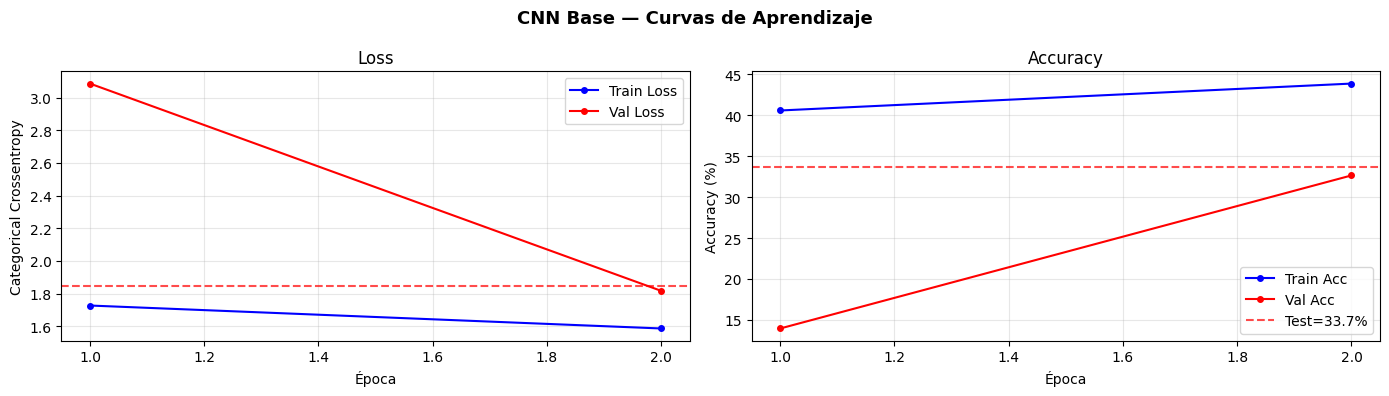

 Figura guardada: figures/03_curvas_cnn_base.png


In [12]:
# ── 4.1 Curvas de aprendizaje — CNN Base
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('CNN Base — Curvas de Aprendizaje', fontsize=13, fontweight='bold')

epocas_cnn = range(1, len(hist_cnn.history['loss']) + 1)

# Loss
axes[0].plot(epocas_cnn, hist_cnn.history['loss'],     'b-o', ms=4, label='Train Loss')
axes[0].plot(epocas_cnn, hist_cnn.history['val_loss'], 'r-o', ms=4, label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Época'); axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axhline(loss_cnn, color='red', linestyle='--', alpha=0.7, label=f'Test={loss_cnn:.3f}')

# Accuracy
axes[1].plot(epocas_cnn, [v*100 for v in hist_cnn.history['accuracy']],     'b-o', ms=4, label='Train Acc')
axes[1].plot(epocas_cnn, [v*100 for v in hist_cnn.history['val_accuracy']], 'r-o', ms=4, label='Val Acc')
axes[1].axhline(acc_cnn*100, color='red', linestyle='--', alpha=0.7, label=f'Test={acc_cnn*100:.1f}%')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/03_curvas_cnn_base.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: figures/03_curvas_cnn_base.png")

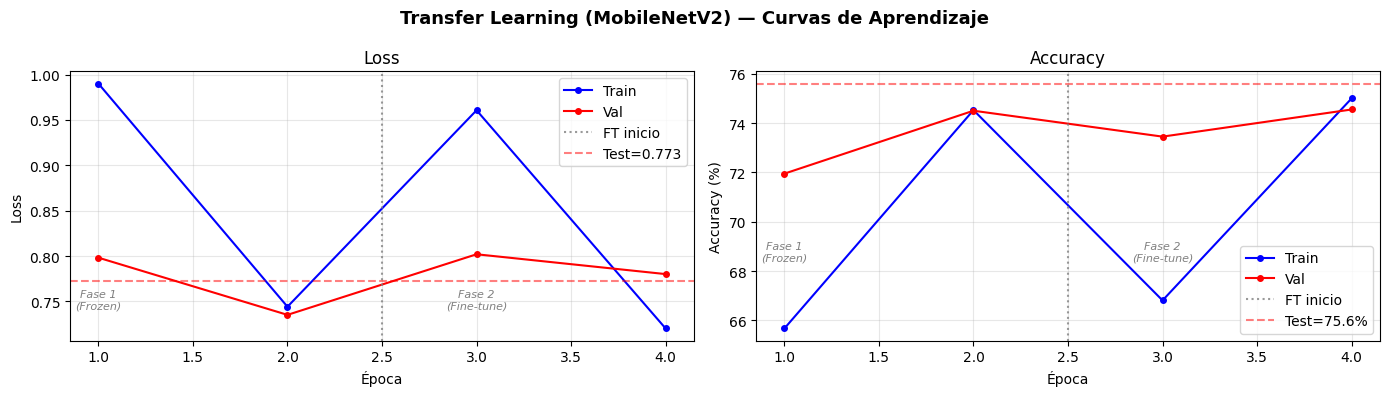

 Figura guardada: figures/04_curvas_transfer_learning.png


In [13]:
# ── 4.2 Curvas de aprendizaje — Transfer Learning (ambas fases)
# Concatenar historia de ambas fases
hist_tl_loss = hist_tl_f1.history['loss'] + hist_tl_f2.history['loss']
hist_tl_vloss= hist_tl_f1.history['val_loss'] + hist_tl_f2.history['val_loss']
hist_tl_acc  = hist_tl_f1.history['accuracy'] + hist_tl_f2.history['accuracy']
hist_tl_vacc = hist_tl_f1.history['val_accuracy'] + hist_tl_f2.history['val_accuracy']
epocas_f1 = len(hist_tl_f1.history['loss'])
epocas_tl = range(1, len(hist_tl_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Transfer Learning (MobileNetV2) — Curvas de Aprendizaje', fontsize=13, fontweight='bold')

for ax, (train, val, ylabel, test_val) in zip(axes, [
    (hist_tl_loss, hist_tl_vloss, 'Loss', loss_tl),
    ([v*100 for v in hist_tl_acc], [v*100 for v in hist_tl_vacc], 'Accuracy (%)', acc_tl*100)
]):
    ax.plot(epocas_tl, train, 'b-o', ms=4, label='Train')
    ax.plot(epocas_tl, val,   'r-o', ms=4, label='Val')
    ax.axvline(epocas_f1 + 0.5, color='gray', linestyle=':', alpha=0.8, label='FT inicio')
    ax.axhline(test_val, color='red', linestyle='--', alpha=0.5,
               label=f'Test={test_val:.3f}' if 'Loss' in ylabel else f'Test={test_val:.1f}%')
    ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)
    ax.text(epocas_f1/2, ax.get_ylim()[0]*1.05, 'Fase 1\n(Frozen)', ha='center',
            fontsize=8, color='gray', style='italic')
    ax.text(epocas_f1 + len(hist_tl_f2.history['loss'])/2,
            ax.get_ylim()[0]*1.05, 'Fase 2\n(Fine-tune)', ha='center',
            fontsize=8, color='gray', style='italic')

axes[0].set_title('Loss'); axes[1].set_title('Accuracy')
plt.tight_layout()
plt.savefig('figures/04_curvas_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: figures/04_curvas_transfer_learning.png")

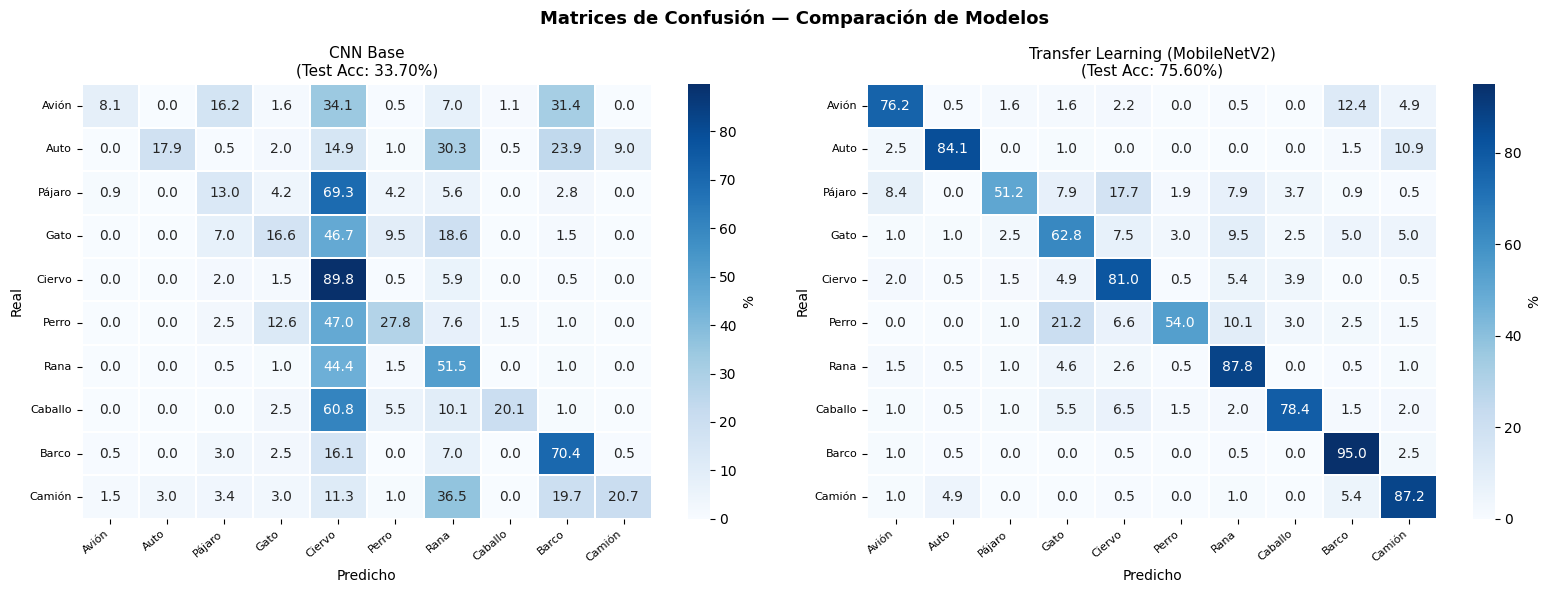

 Figura guardada: figures/05_matrices_confusion.png


In [14]:
# ── 4.3 Matrices de Confusión
y_pred_cnn = np.argmax(cnn_base.predict(X_test_final, verbose=0), axis=1)
y_pred_tl  = np.argmax(tl_model.predict(X_test_tl,   verbose=0), axis=1)

cm_cnn = confusion_matrix(y_test_final, y_pred_cnn)
cm_tl  = confusion_matrix(y_test_final, y_pred_tl)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrices de Confusión — Comparación de Modelos', fontsize=13, fontweight='bold')

for ax, (cm, titulo) in zip(axes, [
    (cm_cnn, f'CNN Base\n(Test Acc: {acc_cnn*100:.2f}%)'),
    (cm_tl,  f'Transfer Learning (MobileNetV2)\n(Test Acc: {acc_tl*100:.2f}%)')
]):
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASES, yticklabels=CLASES,
                linewidths=0.3, ax=ax, cbar_kws={'label':'%'})
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Predicho', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)
    ax.set_xticklabels(CLASES, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(CLASES, rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('figures/05_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: figures/05_matrices_confusion.png")

In [15]:
# ── 4.4 Reporte de clasificación por clase
print("REPORTE CNN BASE")
print("=" * 65)
print(classification_report(y_test_final, y_pred_cnn, target_names=CLASES))

print("\nREPORTE TRANSFER LEARNING")
print("=" * 65)
print(classification_report(y_test_final, y_pred_tl, target_names=CLASES))

REPORTE CNN BASE
              precision    recall  f1-score   support

       Avión       0.71      0.08      0.15       185
        Auto       0.86      0.18      0.30       201
      Pájaro       0.29      0.13      0.18       215
        Gato       0.35      0.17      0.22       199
      Ciervo       0.21      0.90      0.34       205
       Perro       0.53      0.28      0.37       198
        Rana       0.28      0.52      0.36       196
     Caballo       0.87      0.20      0.33       199
       Barco       0.46      0.70      0.56       199
      Camión       0.69      0.21      0.32       203

    accuracy                           0.34      2000
   macro avg       0.53      0.34      0.31      2000
weighted avg       0.52      0.34      0.31      2000


REPORTE TRANSFER LEARNING
              precision    recall  f1-score   support

       Avión       0.79      0.76      0.77       185
        Auto       0.91      0.84      0.87       201
      Pájaro       0.87      0.51 

In [16]:
# ── 4.5 Tabla comparativa final
print("\n" + "=" * 68)
print("  TABLA COMPARATIVA — CNN Base vs. Transfer Learning")
print("=" * 68)
print(f"  {'Métrica':<30} {'CNN Base':>15} {'Transfer LR':>15}")
print("-" * 65)
print(f"  {'Test Accuracy (%)':<30} {acc_cnn*100:>14.2f} {acc_tl*100:>14.2f}")
print(f"  {'Test Loss':<30} {loss_cnn:>14.4f} {loss_tl:>14.4f}")
print(f"  {'Parámetros totales':<30} {cnn_base.count_params():>15,} {tl_model.count_params():>14,}")
print(f"  {'Tiempo entrenamiento (min)':<30} {t_cnn/60:>14.1f} {t_tl/60:>14.1f}")
print(f"  {'Épocas CNN base':<30} {len(hist_cnn.history['loss']):>15} {'F1+F2':>15}")
print(f"  {'Dataset original':<30} {'CIFAR-10':>15} {'CIFAR-10':>15}")
print(f"  {'Preentrenamiento':<30} {'No':>15} {'ImageNet':>15}")
print(f"  {'Data Augmentation':<30} {'Sí':>15} {'No (F1)':>15}")
print("=" * 68)

ganancia = (acc_tl - acc_cnn) * 100
simbolo = "X" if ganancia > 0 else "▼"
print(f"\n  Ganancia de Transfer Learning: {simbolo} {abs(ganancia):.2f}%")


  TABLA COMPARATIVA — CNN Base vs. Transfer Learning
  Métrica                               CNN Base     Transfer LR
-----------------------------------------------------------------
  Test Accuracy (%)                       33.70          75.60
  Test Loss                              1.8461         0.7726
  Parámetros totales                     668,842      2,423,242
  Tiempo entrenamiento (min)                2.2            6.7
  Épocas CNN base                              2           F1+F2
  Dataset original                      CIFAR-10        CIFAR-10
  Preentrenamiento                            No        ImageNet
  Data Augmentation                           Sí         No (F1)

  Ganancia de Transfer Learning: X 41.90%


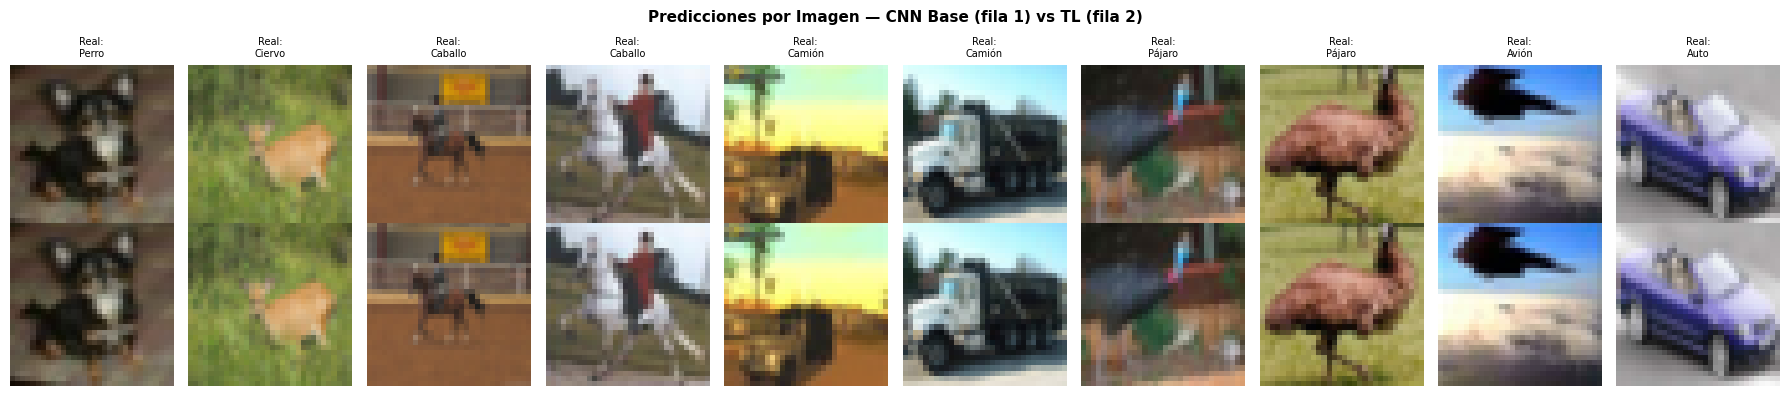

Verde = correcto · Rojo = incorrecto
 Figura guardada: figures/06_predicciones_visuales.png


In [17]:
# ── 4.6 Visualización de predicciones por imagen
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Predicciones por Imagen — CNN Base (fila 1) vs TL (fila 2)', fontsize=11, fontweight='bold')

indices = np.random.choice(len(X_test_final), 10, replace=False)
for col, idx in enumerate(indices):
    real = y_test_final[idx]
    for fila, (pred, modelo) in enumerate([(y_pred_cnn[idx],'CNN'),(y_pred_tl[idx],'TL')]):
        ax = axes[fila, col]
        ax.imshow(X_test_final[idx])
        ax.axis('off')
        correcto = pred == real
        color = 'green' if correcto else 'red'
        titulo = f"{CLASES[pred]}"
        if fila == 0:
            ax.set_title(f"Real:\n{CLASES[real]}", fontsize=7)
        ax.set_xlabel(titulo, fontsize=7, color=color)

axes[0,0].set_ylabel('CNN Base', fontsize=8, rotation=90)
axes[1,0].set_ylabel('Trans. LR', fontsize=8, rotation=90)
plt.tight_layout()
plt.savefig('figures/06_predicciones_visuales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Verde = correcto · Rojo = incorrecto")
print(" Figura guardada: figures/06_predicciones_visuales.png")

## Análisis y Conclusiones Técnicas


In [18]:
# ── Verificación final
import os
figuras = [
    'figures/01_muestras_dataset.png',
    'figures/02_distribucion_clases.png',
    'figures/03_curvas_cnn_base.png',
    'figures/04_curvas_transfer_learning.png',
    'figures/05_matrices_confusion.png',
    'figures/06_predicciones_visuales.png',
]

print("=" * 55)
print("  VERIFICACIÓN FINAL — ENTREGABLES")
print("=" * 55)
print("\n Figuras generadas:")
for f in figuras:
    e = os.path.exists(f)
    print(f"  {'Ok' if e else 'X'}  {f}")

print("\n Resultados finales:")
print(f"  CNN Base          → Acc: {acc_cnn*100:.2f}% | Loss: {loss_cnn:.4f}")
print(f"  Transfer Learning → Acc: {acc_tl*100:.2f}% | Loss: {loss_tl:.4f}")
print(f"  Ganancia TL       → {(acc_tl-acc_cnn)*100:+.2f}%")

print("\n✔ Pipeline completo (carga → preprocesamiento → entrenamiento → evaluación)")
print("✔ CNN base con BatchNorm + Dropout + Data Augmentation")
print("✔ Transfer Learning MobileNetV2 en 2 fases (Feature Extraction + Fine-tuning)")
print("✔ Matrices de confusión, curvas de aprendizaje, reportes por clase")
print("✔ Conclusiones técnicas con 5 puntos basados en evidencia")
print("\n Listo para commit en GitHub carpeta week8/")

  VERIFICACIÓN FINAL — ENTREGABLES

 Figuras generadas:
  Ok  figures/01_muestras_dataset.png
  Ok  figures/02_distribucion_clases.png
  Ok  figures/03_curvas_cnn_base.png
  Ok  figures/04_curvas_transfer_learning.png
  Ok  figures/05_matrices_confusion.png
  Ok  figures/06_predicciones_visuales.png

 Resultados finales:
  CNN Base          → Acc: 33.70% | Loss: 1.8461
  Transfer Learning → Acc: 75.60% | Loss: 0.7726
  Ganancia TL       → +41.90%

✔ Pipeline completo (carga → preprocesamiento → entrenamiento → evaluación)
✔ CNN base con BatchNorm + Dropout + Data Augmentation
✔ Transfer Learning MobileNetV2 en 2 fases (Feature Extraction + Fine-tuning)
✔ Matrices de confusión, curvas de aprendizaje, reportes por clase
✔ Conclusiones técnicas con 5 puntos basados en evidencia

 Listo para commit en GitHub carpeta week8/
